## Basic Setup

In [1]:
import os
import numpy as np
import random
import matplotlib.pyplot as plt
import joblib

from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

os.chdir('../../../') # move three level up to the base path
from src.utils import load_images_from_folder
from src.model_evaluation import evaluate_model

In [2]:
# set the random seeds to make sure that the results are reproducible
SEED = 1234
np.random.seed(SEED)
random.seed(SEED)

In [3]:
model_name = '0_real_eyes'
repo_path = '/Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection'
model_save_path = f'{repo_path}/models/svm/{model_name}/models/{model_name}.joblib'

realDataPath = repo_path + '/data/CEW_Data_Test_Train'
realTrainingPath = realDataPath + '/TrainingSet'
realTestPath = realDataPath + '/TestSet'

train_open_path = realTrainingPath + '/Opened'
train_closed_path = realTrainingPath + '/Closed'
test_open_path = realTestPath + '/Opened'
test_closed_path = realTestPath + '/Closed'

In [4]:
# Load images and labels for training set
train_open_images, train_open_labels = load_images_from_folder(train_open_path, 1)
train_closed_images, train_closed_labels = load_images_from_folder(train_closed_path, 0)

# Combine training data and labels
X_train = np.array(train_open_images + train_closed_images)
y_train = np.array(train_open_labels + train_closed_labels)

# Load images and labels for test set
test_open_images, test_open_labels = load_images_from_folder(test_open_path, 1)
test_closed_images, test_closed_labels = load_images_from_folder(test_closed_path, 0)

# Combine test data and labels
X_test = np.array(test_open_images + test_closed_images)
y_test = np.array(test_open_labels + test_closed_labels)

## Running PCA and SVM

In [5]:
# Apply PCA for dimensionality reduction
pca = PCA(n_components=200, whiten=True, random_state=42)
svc = SVC(kernel='rbf', class_weight='balanced')
model = make_pipeline(pca, svc)

'''
# Grid search for hyperparameter tuning
param_grid = {'svc__C': [1, 5, 10, 50],
              'svc__gamma': [0.0001, 0.0005, 0.001, 0.005]}
grid = GridSearchCV(model, param_grid)
'''

param_grid = {
    'svc__C': [0.5, 1, 1.5, 2],
    'svc__gamma': [0.005, 0.01, 0.02, 0.05]} # Wide range for gamma 
grid = GridSearchCV(model, param_grid, cv=5)  # 5-fold cross-validation

# Fit the model with grid search
grid.fit(X_train, y_train)
print("Best parameters found: ", grid.best_params_)

Best parameters found:  {'svc__C': 2, 'svc__gamma': 0.005}


In [6]:
# Train the SVM classifier with the best parameters
best_model = grid.best_estimator_
best_model.fit(X_train, y_train)

Pipeline(steps=[('pca', PCA(n_components=200, random_state=42, whiten=True)),
                ('svc', SVC(C=2, class_weight='balanced', gamma=0.005))])

In [10]:
joblib.dump(best_model, model_save_path)
model = joblib.load(model_save_path)

Test accuracy: 0.9289
Test precision: 0.9629
Test recall: 0.8945
Test F1 score: 0.9274
Prediction time: 0.84 seconds


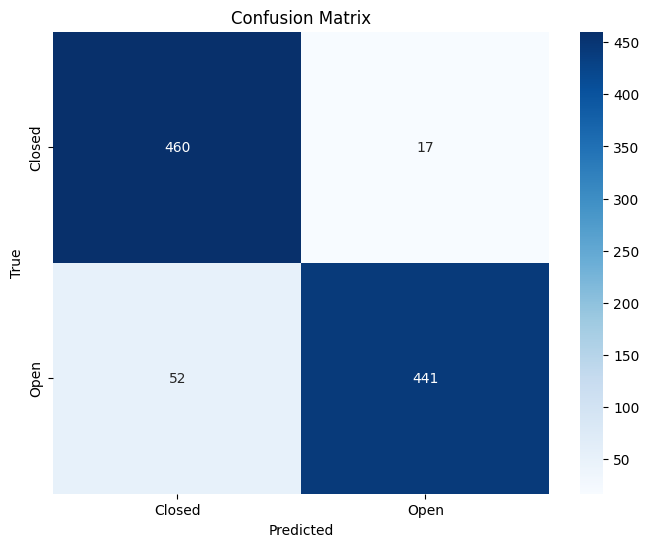

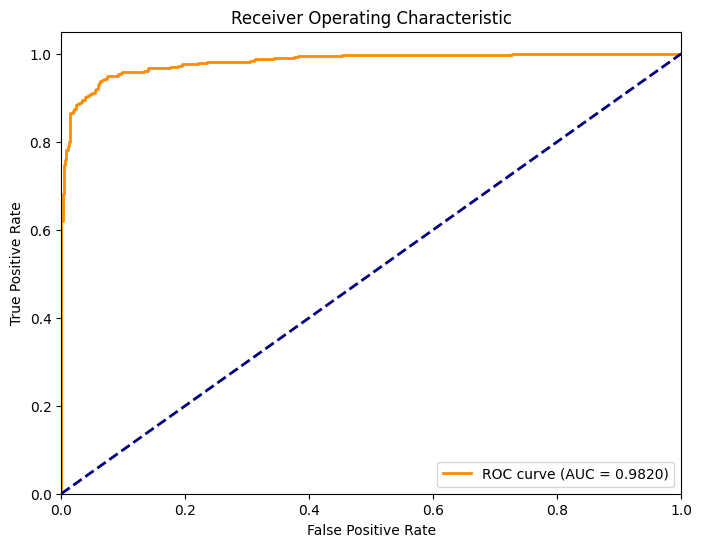

In [7]:
evaluate_model(best_model, (X_test, y_test))

## Additional Data Exploration

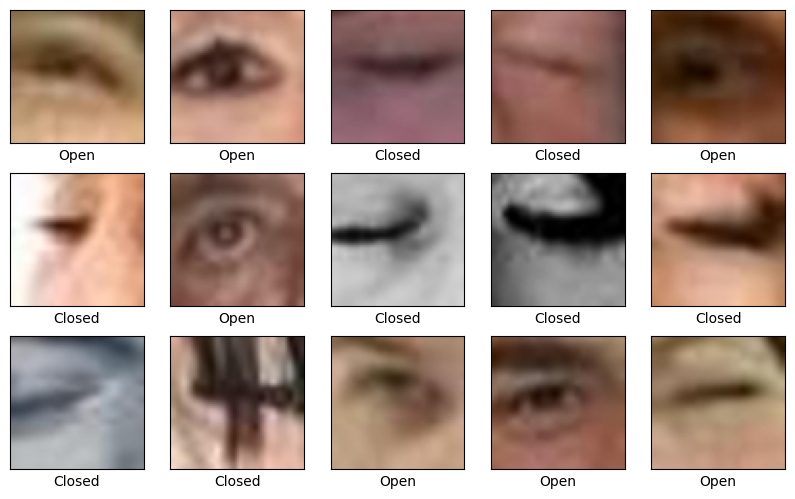

In [8]:
# Randomly shuffle and sample images from both open and closed eye training sets
num_samples = 15  # Total number of images to display (3 rows x 5 columns)
num_open = min(len(train_open_images), num_samples // 2)  # Half from open
num_closed = num_samples - num_open  # Half from closed

sampled_open = random.sample(list(zip(train_open_images, ['Open'] * len(train_open_images))), num_open)
sampled_closed = random.sample(list(zip(train_closed_images, ['Closed'] * len(train_closed_images))), num_closed)
sampled_images = sampled_open + sampled_closed
random.shuffle(sampled_images)

fig, ax = plt.subplots(3, 5, figsize=(10, 6))
for i, axi in enumerate(ax.flat):
    img_array, label = sampled_images[i]
    img = img_array.reshape(64, 64, 3)
    axi.imshow(img)
    axi.set(xticks=[], yticks=[], xlabel=label)
plt.show()

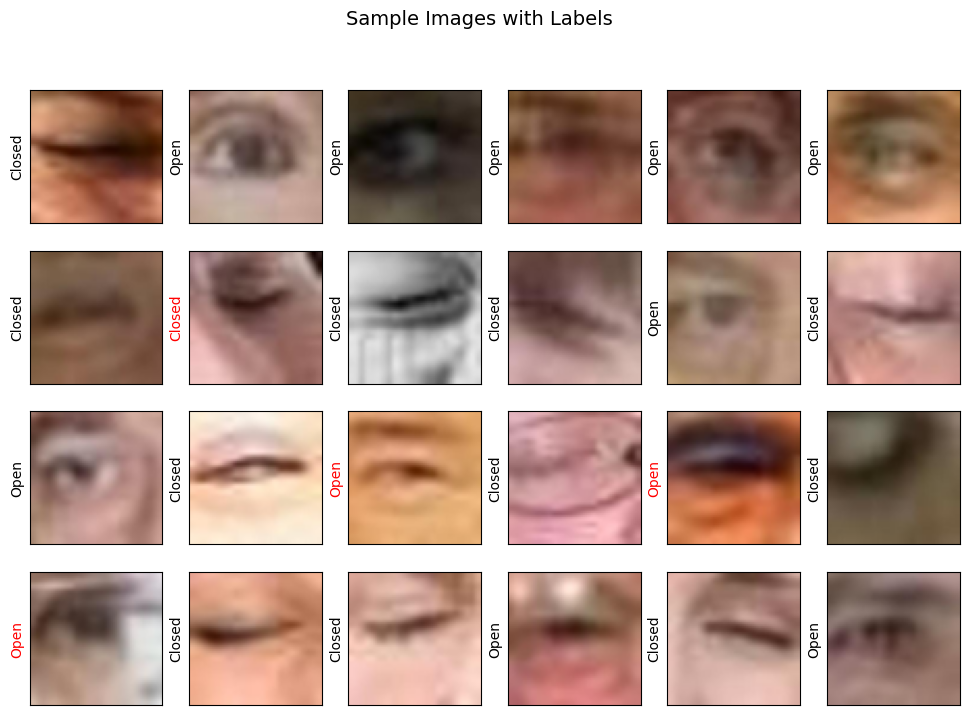

In [9]:
# Generate predictions for the test images
X_test_combined = test_open_images + test_closed_images
y_test_combined = [1] * len(test_open_images) + [0] * len(test_closed_images)
y_pred_combined = best_model.predict(X_test_combined)

# Randomly shuffle and sample images from both open and closed eye test sets
sampled_images_labels = random.sample(list(zip(test_open_images, ['Open'] * len(test_open_images), y_pred_combined[:len(test_open_images)])), 12) + \
                        random.sample(list(zip(test_closed_images, ['Closed'] * len(test_closed_images), y_pred_combined[len(test_open_images):])), 12)
random.shuffle(sampled_images_labels)

fig, ax = plt.subplots(4, 6, figsize=(12, 8))
for i, axi in enumerate(ax.flat):
    img_array, label, pred = sampled_images_labels[i]
    img = img_array.reshape(64, 64, 3)
    correct_label = 'Open' if pred == 1 else 'Closed'
    color = 'black' if label == correct_label else 'red'
    axi.imshow(img)
    axi.set(xticks=[], yticks=[])
    axi.set_ylabel(label, color=color)
fig.suptitle('Sample Images with Labels', size=14)
plt.show()